# Running an aquaplanet test case

First we set up the mpi environment:

In [1]:
from pyrte_rrtmgp.rrtmgp_data_files import download_rrtmgp_data

download_rrtmgp_data()

'/root/.cache/pyrte_rrtmgp/rrtmgp-data-1.9'

In [2]:
import ipyparallel as ipp
ntiles = 6
layout = (1, 1)

num_ranks = ntiles * layout[0] * layout[1]
cluster = ipp.Cluster(engines="mpi", n=num_ranks).start_and_connect_sync()

# start executing cells on the workers in parallel from here on
%autopx

Starting 6 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|███████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.07engine/s]
%autopx enabled


[0:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[10], line 7
      5 fig = plt.figure(figsize=(12, 6))
      6 ax = fig.add_subplot(111, projection=ccrs.Robinson())
----> 7 f1 = pcolormesh_cube(
      8     grid_lat.data[:, :-1, :-1] * 180./np.pi,
      9     grid_lon.data[:, :-1, :-1] * 180./np.pi,
     10     temperature.field[:, :, :, -2],
     11     cmap="viridis",
     12 )
     13 plt.colorbar(f1, label="Temperature (K)")
     14 ax.set_title(f"850 hPa Temperature ({nx} x {nx} points per tile)")

File /fv3net/external/fv3viz/fv3viz/_plot_cube.py:290, in pcolormesh_cube(lat, lon, array, ax, **kwargs)
    261 def pcolormesh_cube(
    262     lat: np.ndarray, lon: np.ndarray, array: np.ndarray, ax: plt.axes = None, **kwargs
    263 ):
    264     """Plots tiled cubed sphere. This function applies nan to gridcells which cross
    265     the antimeridian, and th

[0:execute]
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
Cell In[12], line 2
      1 try:
----> 2     driver.step_all()
      3 finally:
      4     driver.cleanup()

File /pace/pace/driver.py:779, in Driver.step_all(self)
    777 PerformanceCollector.mark_cuda_profiler("Begin integration")
    778 PerformanceCollector.start_cuda_profiler()
--> 779 self._critical_path_step_all(
    780     steps_count=self.config.n_timesteps(),
    781     timer=self.performance_collector.timestep_timer,
    782     dt=Float(self.config.timestep.total_seconds()),
    783 )
    784 PerformanceCollector.stop_cuda_profiler()
    785 self.profiler.dump_stats(
    786     f"{self.config.performance_config.experiment_name}_\
    787     {self.comm.Get_rank()}.prof"
    788 )

File /pace/pace/driver.py:756, in Driver._critical_path_step_all(self, steps_count, timer, dt)
    754         if not self.config

In [3]:
from mpi4py import MPI

mpi_comm = MPI.COMM_WORLD
mpi_size = mpi_comm.Get_size()
mpi_rank = mpi_comm.Get_rank()

print(f"I am MPI-rank {mpi_rank} of a total of {mpi_size}")

[stdout:1] I am MPI-rank 1 of a total of 6


[stdout:0] I am MPI-rank 0 of a total of 6


[stdout:4] I am MPI-rank 4 of a total of 6


[stdout:5] I am MPI-rank 5 of a total of 6


[stdout:2] I am MPI-rank 2 of a total of 6


[stdout:3] I am MPI-rank 3 of a total of 6


In [4]:
#%%capture

from pace import Driver, DriverConfig
import yaml
import os

os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

config_file = "aquaplanet_c16.yaml"

with open(config_file, "r") as f:
    driver_config = DriverConfig.from_dict(yaml.safe_load(f))
driver = Driver(config=driver_config)

[output:5]

[output:2]

[output:0]

[output:1]

[output:4]

...

%px:   0%|                                                                       | 0/6 [00:03<?, ?tasks/s]

[stderr:3] /usr/local/lib/python3.12/site-packages/pyfv3/initialization/init_utils.py:504: RuntimeWarning: invalid value encountered in scalar divide
  pt[i, j, k] = (gz[i, k] - gz[i, k+1]) / (constants.RDGAS * (
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/ndsl/initialization/allocator.py:262: UserWarning: Found inconsistency with number of halo points in Quantity:2 vs 3
  return temp_quantity.halo_spec(n_halo)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitial

[stderr:4] /usr/local/lib/python3.12/site-packages/pyfv3/initialization/init_utils.py:504: RuntimeWarning: invalid value encountered in scalar divide
  pt[i, j, k] = (gz[i, k] - gz[i, k+1]) / (constants.RDGAS * (
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/ndsl/initialization/allocator.py:262: UserWarning: Found inconsistency with number of halo points in Quantity:2 vs 3
  return temp_quantity.halo_spec(n_halo)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitial

[stderr:1] /usr/local/lib/python3.12/site-packages/pyfv3/initialization/init_utils.py:504: RuntimeWarning: invalid value encountered in scalar divide
  pt[i, j, k] = (gz[i, k] - gz[i, k+1]) / (constants.RDGAS * (
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/ndsl/initialization/allocator.py:262: UserWarning: Found inconsistency with number of halo points in Quantity:2 vs 3
  return temp_quantity.halo_spec(n_halo)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitial

%px: 100%|███████████████████████████████████████████████████████████████| 6/6 [03:02<00:00, 30.49s/tasks]


In [5]:
if mpi_rank == 0:
    print(driver.state.grid_data.lon_agrid.shape)

[stdout:0] (23, 23)


We can inspect the initial model state:

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube
from ndsl import CubedSphereCommunicator

communicator = CubedSphereCommunicator.from_layout(
    comm=driver.comm,
    layout=driver.config.layout,
)
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)

In [11]:
if mpi_rank == 0:
    print(temperature.shape)
    print(grid_lon.data.shape)
    print(grid_lat.shape)
    print(driver.state.dycore_state.pt.shape)

[stdout:0] (6, 16, 16, 79)
(6, 17, 17)
(6, 17, 17)
(23, 23, 80)


[output:0]

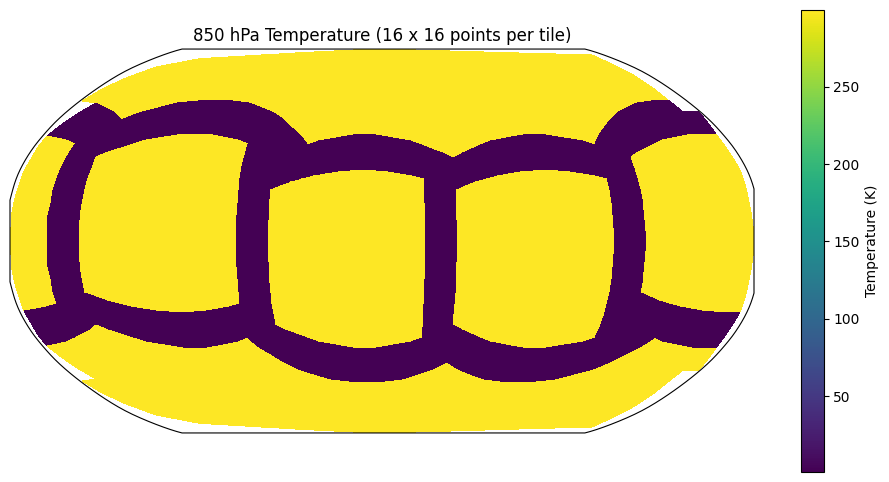

In [13]:
if mpi_rank == 0:
    u_mean = 0.5 * (u_wind.field[:,:,:-1, :] + u_wind.field[:,:, 1:, :])
    
    nx = temperature.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        temperature.field[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"850 hPa Temperature ({nx} x {nx} points per tile)")
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         surface_pressure.data[:, :, :]/100.,
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="Surface Pressure (hPa)")
#     ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         u_mean[:,:,:,65],
#         cmap="bwr",
#     )
#     plt.colorbar(f1, label="U wind (m/s)")
#     ax.set_title(f"U Wind ({nx} x {nx} points per tile)")

And then we can run the model:

In [14]:
try:
    driver.step_all()
finally:
    driver.cleanup()

[stdout:0] 2026-01-28 16:17:21|INFO|rank 0|ndsl.logging:integrating driver forward in time
2026-01-28 16:17:21|INFO|rank 0|ndsl.logging:FV Setup
2026-01-28 16:17:21|INFO|rank 0|ndsl.logging:Adjust pt
2026-01-28 16:17:21|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|INFO|rank 0|ndsl.logging:DynCore
2026-01-28 16:17:21|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 17 < 22.
2

[stdout:1] 2026-01-28 16:17:21|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-01-28 16:17:21|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 1|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 

[stdout:2] 2026-01-28 16:17:21|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-01-28 16:17:21|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 2|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 

[stdout:5] 2026-01-28 16:17:21|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-01-28 16:17:21|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 5|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 

[stdout:3] 2026-01-28 16:17:21|INFO|rank 3|ndsl.logging:integrating driver forward in time
2026-01-28 16:17:21|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 3|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 

[stdout:4] 2026-01-28 16:17:21|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-01-28 16:17:21|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 16 < 22.
2026-01-28 16:17:21|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 4|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 17 < 22.
2026-01-28 16:17:21|WARNING|rank 

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



%px: 100%|███████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.89tasks/s]


AlreadyDisplayedError: 6 errors

Now let's investigate the model state

In [ ]:
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
qrain = communicator.gather(driver.state.dycore_state.qrain)

In [ ]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_pressure.data[:, :, :]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qcld,
        cmap="viridis",
    )
    plt.colorbar(f1, label="cloud mixing ratio")
    ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")